1. Install & Import Libraries

In [ ]:
# nltk for NLP preprocessing
import nltk
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


True

In [ ]:


# Removed explicit jax installation to avoid conflicts with pre-installed TensorFlow

import numpy as np
import pandas as pd
import re
import string
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
# Import time module to measure model training duration
import time
import nltk

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer, PorterStemmer
from sklearn.preprocessing import LabelEncoder

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Embedding, SimpleRNN, LSTM
from tensorflow.keras.callbacks import EarlyStopping

#2 Load Dataset

The dataset contains:
- headline: News headline text
- category: Corresponding category label

The objective is to classify headlines into their respective categories.



In [ ]:
# Mount Google Drive to access the dataset. This allows the Colab environment to access files stored in your Google Drive.
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:

file_path = "/content/drive/My Drive/Dataset/News/news_category.csv"

df = pd.read_csv(file_path)

# Keep only required columns
df = df[['headline', 'category']]

# Check
df.head()

print("Dataset shape:", df.shape)
print("Number of classes:", df['category'].nunique())
print(df['category'].value_counts())

Dataset shape: (11025, 2)
Number of classes: 5
category
SPORTS            5077
TECH              2104
MONEY             1756
CULTURE & ARTS    1074
EDUCATION         1014
Name: count, dtype: int64


## Dataset Class Distribution

This cell visualizes how many samples are available in each category. This is important because imbalanced classes can affect model performance.

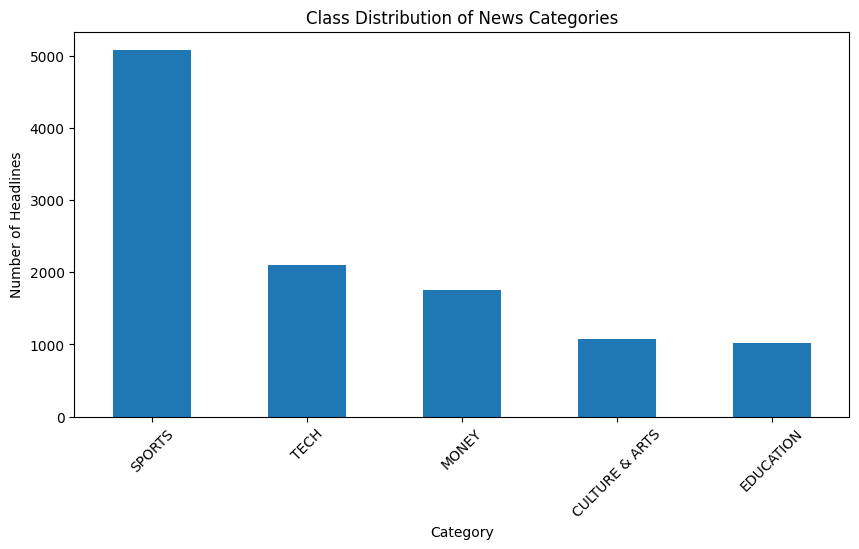

In [ ]:
# Plot the number of headlines in each category
plt.figure(figsize=(10, 5))

# Count each category and create a bar chart
df['category'].value_counts().plot(kind='bar')

# Add title and labels for clear understanding
plt.title('Class Distribution of News Categories')
plt.xlabel('Category')
plt.ylabel('Number of Headlines')

# Rotate x-axis labels for readability
plt.xticks(rotation=45)

plt.show()

3. Text Preprocessing
Preprocessing steps include:
- Lowercasing text
- Removing URLs, mentions, hashtags, and special characters
- Removing stopwords
- Applying lemmatization

These steps improve model performance by reducing noise.


## Sample of News Category Dataset

This section displays a small sample of the dataset used in this project. The dataset contains news headlines and their corresponding category labels.

In [ ]:
# Display first 10 rows of the dataset
# This helps understand the structure of the dataset

sample_df = df[['headline', 'category']].head(10)

# Show dataset sample
sample_df

,headline,category
0,How A New Documentary Captures The Complexity ...,CULTURE & ARTS
1,Twitch Bans Gambling Sites After Streamer Scam...,TECH
2,'Reboot' Is A Clever And Not Too Navel-Gazey L...,CULTURE & ARTS
3,"Maury Wills, Base-Stealing Shortstop For Dodge...",SPORTS
4,"Las Vegas Aces Win First WNBA Title, Chelsea G...",SPORTS
5,"Meet Alex Aster, The TikToker Changing The Pub...",CULTURE & ARTS
6,TikTok Search Results Riddled With Misinformat...,TECH
7,Boston Marathon To Make Race More Inclusive Fo...,SPORTS
8,"Anthony Varvaro, MLB Pitcher Turned Transit Co...",SPORTS
9,How Ani Liu Is Brilliantly Disguising Her Art ...,CULTURE & ARTS


In [ ]:
# Contraction mapping for expanding common English contractions
CONTRACTIONS = {
    "don't": "do not", "can't": "cannot", "won't": "will not",
    "n't": " not", "'re": " are", "'s": " is", "'ll": " will",
    "'ve": " have", "'m": " am", "'d": " would", "ain't": "am not",
    "let's": "let us", "couldn't": "could not", "wouldn't": "would not",
    "shouldn't": "should not", "doesn't": "does not", "didn't": "did not"
}

def expand_contractions(text: str) -> str:
    """Replace contractions with full forms (e.g., 'don't' -> 'do not')."""
    for short, full in CONTRACTIONS.items():
        text = text.replace(short, full)
    return text

# Initialize stopwords and lemmatizer
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    """
    Cleans raw text by removing noise and normalizing words.
    Steps: lowercasing, contraction expansion, removal of URLs/mentions/hashtags/special chars,
    tokenization, stopword removal, and lemmatization.
    """
    text = str(text).lower()
    text = expand_contractions(text)                # Expand contractions

    # Remove unwanted patterns
    text = re.sub(r"http\S+", "", text)             # Remove URLs
    text = re.sub(r"@\w+", "", text)                # Remove mentions (@user)
    text = re.sub(r"#\w+", "", text)                # Remove hashtags
    text = re.sub(r"[^a-zA-Z\s]", "", text)         # Remove special characters

    # Tokenize and clean words
    words = text.split()

    # Remove stopwords and apply lemmatization
    words = [lemmatizer.lemmatize(w) for w in words if w not in stop_words]

    return " ".join(words)

# Apply preprocessing to headline column
df['clean_text'] = df['headline'].apply(clean_text)

Word Cloud Visualization

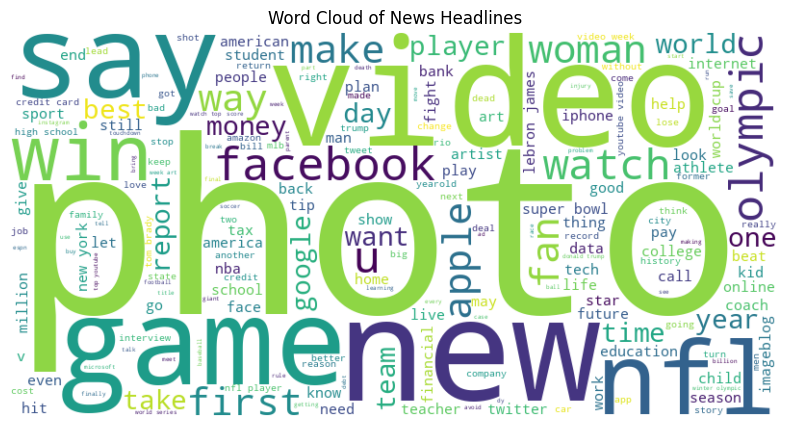

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt



# Combine all cleaned text into one large string
all_text = " ".join(df['clean_text'])

# Generate word cloud
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(all_text)

# Display
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of News Headlines')
plt.show()

4. Tokenization & Encoding


Text is converted into numerical sequences using a tokenizer.

Padding ensures uniform sequence length using the 95th percentile to avoid extremely long inputs.

Labels are encoded using LabelEncoder for multi-class classification.

In [ ]:
# TOKENIZATION: Convert cleaned text into numerical form

# Create tokenizer with maximum vocabulary size
tokenizer = Tokenizer(num_words=10000, oov_token="<OOV>")

# Learn vocabulary from cleaned headline text
tokenizer.fit_on_texts(df['clean_text'])

# Convert each headline into a sequence of word indexes
sequences = tokenizer.texts_to_sequences(df['clean_text'])

# Use 95th percentile length to avoid very long sequences
max_len = int(np.percentile([len(s) for s in sequences], 95))

# Make sure max_len is at least 1
max_len = max(max_len, 1)

# Pad all sequences to same length
X = pad_sequences(sequences, maxlen=max_len, padding='post', truncating='post')

# Encode category labels into numbers
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(df['category'])

# Number of output classes
num_classes = len(label_encoder.classes_)

# Vocabulary size for embedding layer
vocab_size = min(10000, len(tokenizer.word_index) + 1)

# Stratified split keeps same class distribution in train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Maximum sequence length:", max_len)
print("Vocabulary size:", vocab_size)
print("Number of classes:", num_classes)
print("Classes:", label_encoder.classes_)
print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Maximum sequence length: 11
Vocabulary size: 10000
Number of classes: 5
Classes: ['CULTURE & ARTS' 'EDUCATION' 'MONEY' 'SPORTS' 'TECH']
Training samples: 8820
Testing samples: 2205


5. Model 1: Simple RNN


This model uses a Simple Recurrent Neural Network to capture sequential dependencies in text.

However, RNNs suffer from vanishing gradient problems, which limits their ability to learn long-term dependencies.

In [ ]:
# MODEL 1: SIMPLE RNN

model_rnn = Sequential()

# Embedding layer converts word indexes into dense vectors
model_rnn.add(Embedding(
    input_dim=vocab_size,
    output_dim=64
))

# SimpleRNN learns sequential text patterns
model_rnn.add(SimpleRNN(64))

# Output layer for multi-class classification
model_rnn.add(Dense(num_classes, activation='softmax'))

# Build model before summary
model_rnn.build(input_shape=(None, max_len))

# Compile the model
model_rnn.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

# Display model architecture summary
model_rnn.summary()

# Start timer
start_time = time.time()

# Train model with early stopping
history_rnn = model_rnn.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=10,
    batch_size=32,
    callbacks=[EarlyStopping(
        patience=2,
        restore_best_weights=True
    )]
)

# End timer
rnn_training_time = time.time() - start_time

print("RNN Training Time:", round(rnn_training_time, 2), "seconds")

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 11, 64)         │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 648,581 (2.47 MB)

 Trainable params: 648,581 (2.47 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
221/221 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - accuracy: 0.6460 - loss: 0.9458 - val_accuracy: 0.8056 - val_loss: 0.5875
Epoch 2/10
221/221 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9046 - loss: 0.2947 - val_accuracy: 0.8061 - val_loss: 0.5959
Epoch 3/10
221/221 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9762 - loss: 0.0891 - val_accuracy: 0.8084 - val_loss: 0.6622
RNN Training Time: 9.47 seconds


6. Model 2: LSTM


### Model 2: LSTM

LSTM (Long Short-Term Memory) networks are designed to overcome the limitations of RNNs.

They can capture long-term dependencies using memory cells and gating mechanisms, making them more effective for text classification.

In [ ]:
# MODEL 2: LSTM

model_lstm = Sequential()

# Embedding layer converts word indexes into dense vectors
model_lstm.add(Embedding(
    input_dim=vocab_size,
    output_dim=64
))

# LSTM layer captures long-term dependencies in text
model_lstm.add(LSTM(64))

# Output layer for multi-class classification
model_lstm.add(Dense(num_classes, activation='softmax'))

# Build model before displaying summary
model_lstm.build(input_shape=(None, max_len))

# Compile the model
model_lstm.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

# Display model architecture
model_lstm.summary()

# Start timer
start_time = time.time()

# Train model with early stopping
history_lstm = model_lstm.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=10,
    batch_size=32,
    callbacks=[EarlyStopping(
        patience=2,
        restore_best_weights=True
    )]
)

# End timer
lstm_training_time = time.time() - start_time

print("LSTM Training Time:", round(lstm_training_time, 2), "seconds")

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 11, 64)         │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 673,349 (2.57 MB)

 Trainable params: 673,349 (2.57 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
221/221 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.6015 - loss: 1.0249 - val_accuracy: 0.7483 - val_loss: 0.6559
Epoch 2/10
221/221 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.8478 - loss: 0.4309 - val_accuracy: 0.8305 - val_loss: 0.4896
Epoch 3/10
221/221 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9430 - loss: 0.1821 - val_accuracy: 0.8373 - val_loss: 0.5229
Epoch 4/10
221/221 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9738 - loss: 0.0881 - val_accuracy: 0.8254 - val_loss: 0.6237
LSTM Training Time: 13.6 seconds


7. Model 3: Pretrained GloVe Embedding + LSTM

This model uses pretrained GloVe embeddings from gensim. Although the assignment mentions Word2Vec, GloVe is also a pretrained word embedding technique and is loaded from the provided gensim API.

In [ ]:
import sys

# Install gensim in Google Colab if needed
if 'google.colab' in sys.modules:
    %pip install gensim

import gensim.downloader as api

# Load pretrained GloVe embedding model
embedding_model = api.load('glove-wiki-gigaword-50')

# GloVe model has 50-dimensional word vectors
embedding_dim = 50

# Create embedding matrix with zeros
embedding_matrix = np.zeros((vocab_size, embedding_dim))

# Fill embedding matrix with pretrained vectors where available
for word, i in tokenizer.word_index.items():
    if i < vocab_size:
        if word in embedding_model:
            embedding_matrix[i] = embedding_model[word]

# MODEL 3: LSTM WITH PRETRAINED GLOVE EMBEDDING

model_w2v = Sequential()

# Pretrained embedding layer is frozen
model_w2v.add(Embedding(
    input_dim=vocab_size,
    output_dim=embedding_dim,
    weights=[embedding_matrix],
    input_length=max_len,
    trainable=False
))

# LSTM layer learns sequence patterns
model_w2v.add(LSTM(64))

# Output layer for multi-class category prediction
model_w2v.add(Dense(num_classes, activation='softmax'))

# Compile model
model_w2v.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

# Display model architecture
model_w2v.summary()

# Start timer
start_time = time.time()

# Train model
history_w2v = model_w2v.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=10,
    batch_size=32,
    callbacks=[EarlyStopping(patience=2, restore_best_weights=True)]
)

# End timer
w2v_training_time = time.time() - start_time

print("Pretrained GloVe LSTM Training Time:", round(w2v_training_time, 2), "seconds")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 58.9 MB/s eta 0:00:00
[==================================================] 100.0% 66.0/66.0MB downloaded


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │       500,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 500,000 (1.91 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 500,000 (1.91 MB)

Epoch 1/10
221/221 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.7432 - loss: 0.7195 - val_accuracy: 0.8061 - val_loss: 0.5348
Epoch 2/10
221/221 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.8363 - loss: 0.4805 - val_accuracy: 0.8282 - val_loss: 0.4791
Epoch 3/10
221/221 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.8522 - loss: 0.4327 - val_accuracy: 0.8316 - val_loss: 0.4569
Epoch 4/10
221/221 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.8617 - loss: 0.3983 - val_accuracy: 0.8339 - val_loss: 0.4629
Epoch 5/10
221/221 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8729 - loss: 0.3677 - val_accuracy: 0.8441 - val_loss: 0.4294
Epoch 6/10
221/221 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8841 - loss: 0.3406 - val_accuracy: 0.8396 - val_loss: 0.4513
Epoch 7/10
221/221 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8946 - loss: 0.3147 - val_accuracy: 0.8469 - val_loss: 0.4363
Pretrained GloVe LSTM Training Time: 13.12 seconds


8. Evaluation


The models are evaluated using:
- Accuracy
- Confusion Matrix
- Precision, Recall, and F1-score

These metrics provide a comprehensive understanding of model performance.

In [ ]:
# MODEL EVALUATION FUNCTION

from sklearn.metrics import accuracy_score, precision_recall_fscore_support

def evaluate_model(model, name):
    """
    Evaluates a trained model using accuracy, confusion matrix,
    precision, recall, and F1-score.
    """

    # Predict class probabilities
    y_pred_probs = model.predict(X_test)

    # Convert probabilities into class labels
    y_pred = np.argmax(y_pred_probs, axis=1)

    print(f"\n{name} Results")

    # Accuracy score
    accuracy = accuracy_score(y_test, y_pred)
    print("Accuracy:", round(accuracy, 4))

    # Confusion matrix
    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

    # Classification report with class names
    print("\nClassification Report:")
    print(classification_report(
        y_test,
        y_pred,
        target_names=label_encoder.classes_,
        zero_division=0
    ))

    # Weighted metrics are suitable for imbalanced multi-class data
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_test,
        y_pred,
        average='weighted',
        zero_division=0
    )

    return accuracy, precision, recall, f1


# Evaluate all three models
rnn_results = evaluate_model(model_rnn, "Simple RNN")
lstm_results = evaluate_model(model_lstm, "LSTM")
w2v_results = evaluate_model(model_w2v, "Pretrained GloVe LSTM")

69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step

Simple RNN Results
Accuracy: 0.7905

Confusion Matrix:
[[151   6  29  20   9]
 [  0 111  48  21  23]
 [ 31  30 242  24  24]
 [ 21  13  18 950  13]
 [ 21  20  45  46 289]]

Classification Report:
                precision    recall  f1-score   support

CULTURE & ARTS       0.67      0.70      0.69       215
     EDUCATION       0.62      0.55      0.58       203
         MONEY       0.63      0.69      0.66       351
        SPORTS       0.90      0.94      0.92      1015
          TECH       0.81      0.69      0.74       421

      accuracy                           0.79      2205
     macro avg       0.73      0.71      0.72      2205
  weighted avg       0.79      0.79      0.79      2205

69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step

LSTM Results
Accuracy: 0.8336

Confusion Matrix:
[[174   1  16  19   5]
 [  7 123  37  20  16]
 [ 36   8 267  22  18]
 [ 20   6  12 951  26]
 [ 31   9  20  38 323]]

Classification Report:
                precision    

9. Plot Graphs

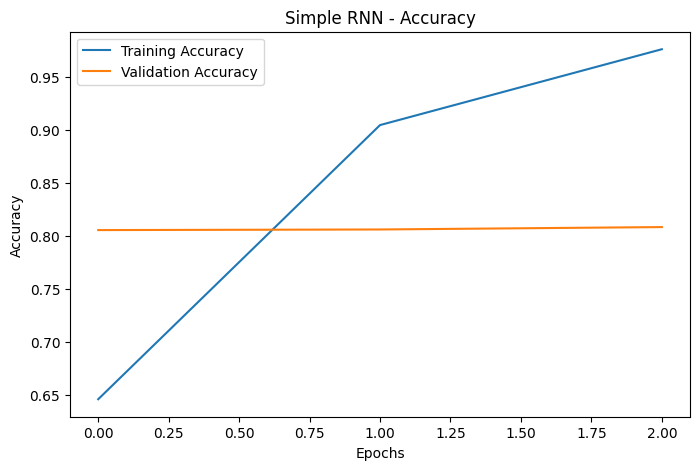

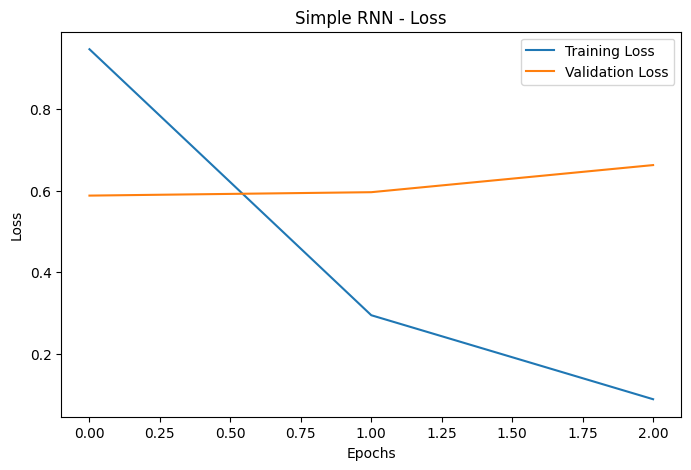

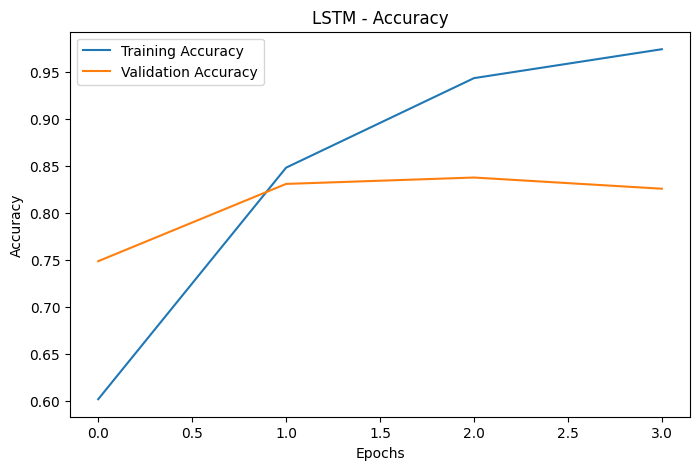

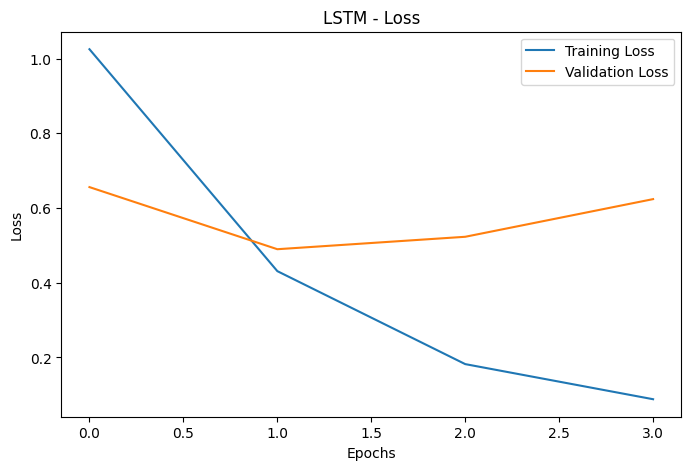

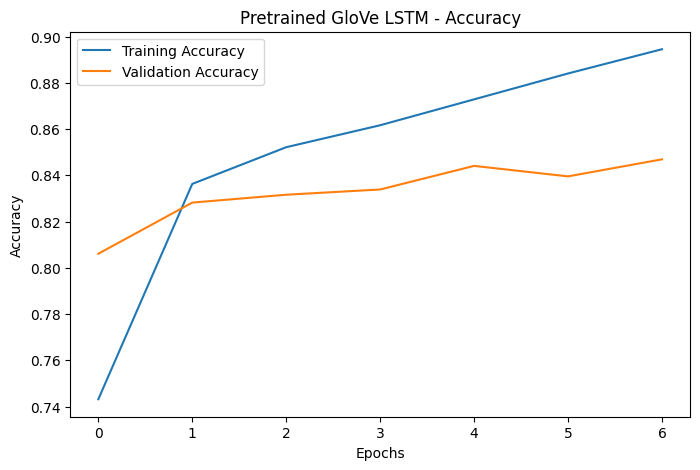

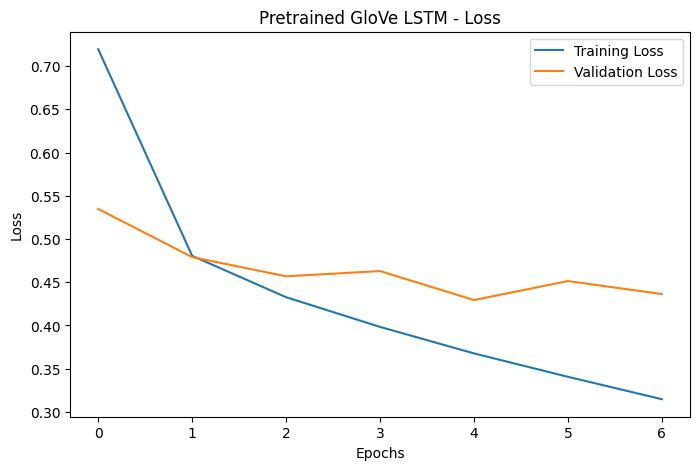

In [ ]:
# VISUALIZE TRAINING ACCURACY AND LOSS

def plot_history(history, title):
    """
    Plots training vs validation accuracy and loss.
    These graphs help identify overfitting or underfitting.
    """

    # Accuracy plot
    plt.figure(figsize=(8, 5))
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title(title + ' - Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.show()

    # Loss plot
    plt.figure(figsize=(8, 5))
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title(title + ' - Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()


plot_history(history_rnn, "Simple RNN")
plot_history(history_lstm, "LSTM")
plot_history(history_w2v, "Pretrained GloVe LSTM")

## Model Performance Comparison

This table compares all three models using accuracy, precision, recall, F1-score, and training time. This is required for the Experiments and Results section of the final report.

In [ ]:
# Create comparison table for all models
comparison_df = pd.DataFrame({
    'Model': ['Simple RNN', 'LSTM', 'Pretrained GloVe LSTM'],
    'Accuracy': [rnn_results[0], lstm_results[0], w2v_results[0]],
    'Precision': [rnn_results[1], lstm_results[1], w2v_results[1]],
    'Recall': [rnn_results[2], lstm_results[2], w2v_results[2]],
    'F1-score': [rnn_results[3], lstm_results[3], w2v_results[3]],
    'Training Time (seconds)': [rnn_training_time, lstm_training_time, w2v_training_time]
})

# Round values for clean display
comparison_df = comparison_df.round(4)

comparison_df

,Model,Accuracy,Precision,Recall,F1-score,Training Time (seconds)
0,Simple RNN,0.7905,0.7896,0.7905,0.7885,9.4679
1,LSTM,0.8336,0.8369,0.8336,0.8323,13.6010
2,Pretrained GloVe LSTM,0.8440,0.8448,0.8440,0.8442,13.1199


10. Error Analysis

In [ ]:
# ERROR ANALYSIS: SHOW MISCLASSIFIED EXAMPLES

# Predict using the best/final model
y_pred = np.argmax(model_w2v.predict(X_test), axis=1)

# Find indexes where prediction is incorrect
wrong_indexes = np.where(y_pred != y_test)[0]

print("Total misclassified examples:", len(wrong_indexes))

# Show 3 incorrect predictions
for index in wrong_indexes[:3]:
    print("Headline:", df.iloc[index]['headline'])
    print("Cleaned Text:", df.iloc[index]['clean_text'])
    print("Actual Category:", label_encoder.inverse_transform([y_test[index]])[0])
    print("Predicted Category:", label_encoder.inverse_transform([y_pred[index]])[0])
    print("Possible Reason: The headline may contain limited words, overlapping topic terms, or unclear context.")
    print("-" * 80)

69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Total misclassified examples: 344
Headline: Twitch Bans Gambling Sites After Streamer Scams Folks Out Of $200,000
Cleaned Text: twitch ban gambling site streamer scam folk
Actual Category: TECH
Predicted Category: SPORTS
Possible Reason: The headline may contain limited words, overlapping topic terms, or unclear context.
--------------------------------------------------------------------------------
Headline: 'Reboot' Is A Clever And Not Too Navel-Gazey Look Inside TV Reboots
Cleaned Text: areboot clever navelgazey look inside tv reboots
Actual Category: EDUCATION
Predicted Category: SPORTS
Possible Reason: The headline may contain limited words, overlapping topic terms, or unclear context.
--------------------------------------------------------------------------------
Headline: Las Vegas Aces Win First WNBA Title, Chelsea Gray Named MVP
Cleaned Text: la vega ace win first wnba title chelsea gray named mvp
Actual Category: CULTURE & ARTS
Predict

Real‑Time Prediction Interface (Gradio)

In [ ]:
import gradio as gr

def predict_category(headline):
    """Clean input, tokenize, pad, and predict category using trained model."""
    cleaned = clean_text(headline)                     # reuse your cleaning function
    seq = tokenizer.texts_to_sequences([cleaned])
    padded = pad_sequences(seq, maxlen=max_len)
    pred_class = np.argmax(model_w2v.predict(padded, verbose=0), axis=1)[0]
    return label_encoder.inverse_transform([pred_class])[0]

# Build and launch the interface
iface = gr.Interface(
    fn=predict_category,
    inputs=gr.Textbox(lines=2, placeholder="Enter a headline..."),
    outputs="text",
    title="News Category Classifier",
    description="Predicts SPORTS, TECH, MONEY, CULTURE & ARTS, or EDUCATION."
)
iface.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://a0432806bb370b33d5.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
